# DX799 Week 2: Education, Voting, and Regularization
**Erica Yanoshak | Linear Regression Part 2**

**Question:** Does regularization improve prediction in the education-based county voting model developed in Week 1?

The corrected RUCC panel contains **12,430 county-year observations from 3,116 counties**, covering 2012, 2016, 2020, and 2024. The outcome is Republican minus Democratic two-party vote share.

**Main finding:** OLS, ridge, lasso, and elastic net performed almost identically. Regularization offered little predictive improvement or variable selection for this feature set.


## 1. Data and Validation
Place the original RUCC CSV beside this notebook, or retain the original `../01_SOURCE_DATA/` location. Run cells in order. The filename says 12,432; the observed dataset has 12,430 rows.

Missing values occur in the separate RUCC vintage columns (`rucc_code_2013` and `rucc_code_2023`), but the final `rural_urban_code` predictor and all other modeling inputs are complete.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV

filename = "DX799_county_year_panel_2012_2024_RUCC_n12432.csv"
data_path = Path(filename)
if not data_path.exists():
    data_path = Path("../01_SOURCE_DATA") / filename

county_panel_df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("File:", data_path.name)
print("Observed shape:", county_panel_df.shape)


Dataset loaded successfully.
File: DX799_county_year_panel_2012_2024_RUCC_n12432.csv
Observed shape: (12430, 24)


In [2]:
required_columns = [
    "year",
    "state",
    "county_fips",
    "county",
    "dem_share",
    "rep_share",
    "vote_margin",
    "pol_intensity",
    "median_income",
    "median_income_z",
    "advanced_degree_pct",
    "white_pct",
    "rural_urban_code"
]

missing_required_columns = [
    column for column in required_columns
    if column not in county_panel_df.columns
]

if missing_required_columns:
    raise ValueError(
        f"Required columns are missing: {missing_required_columns}"
    )

print("Required-column check: PASS")

print("\nElection years:")
print(sorted(county_panel_df["year"].unique()))

print("\nRows by election year:")
print(county_panel_df["year"].value_counts().sort_index())

print("\nUnique counties:")
print(county_panel_df["county_fips"].nunique())

print("\nDuplicate county-year records:")
print(
    county_panel_df
    .duplicated(subset=["county_fips", "year"])
    .sum()
)

print("\nColumns with missing values:")
missing_by_column = (
    county_panel_df.isna()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)
display(missing_by_column.to_frame("missing_count"))


Required-column check: PASS

Election years:
[np.int64(2012), np.int64(2016), np.int64(2020), np.int64(2024)]

Rows by election year:
year
2012    3115
2016    3113
2020    3106
2024    3096
Name: count, dtype: int64

Unique counties:
3116

Duplicate county-year records:
0

Columns with missing values:


,missing_count
rucc_code_2023,18
rucc_code_2013,1


In [3]:
vote_margin_difference = (
    county_panel_df["vote_margin"]
    - (county_panel_df["rep_share"] - county_panel_df["dem_share"])
).abs()

pol_intensity_difference = (
    county_panel_df["pol_intensity"]
    - county_panel_df["vote_margin"].abs()
).abs()

print("Maximum |vote_margin - (rep_share - dem_share)|:")
print(vote_margin_difference.max())

print("\nAll vote margins validate:")
print((vote_margin_difference <= 1e-12).all())

print("\nMaximum |pol_intensity - abs(vote_margin)|:")
print(pol_intensity_difference.max())

print("\nAll county one-sidedness values validate:")
print((pol_intensity_difference <= 1e-12).all())


Maximum |vote_margin - (rep_share - dem_share)|:
2.220446049250313e-16

All vote margins validate:
True

Maximum |pol_intensity - abs(vote_margin)|:
0.0

All county one-sidedness values validate:
True


In [4]:
input_columns = ["advanced_degree_pct", "median_income", "white_pct", "rural_urban_code", "year"]

X = county_panel_df[input_columns].copy()
y = county_panel_df["vote_margin"].copy()
groups = county_panel_df["county_fips"].copy()

assert not X.isna().any().any(), "Missing predictor values"
assert not y.isna().any(), "Missing outcome values"
assert not groups.isna().any(), "Missing county identifiers"
assert np.isfinite(X.to_numpy(dtype=float)).all(), "Nonfinite predictor values"
assert np.isfinite(y.to_numpy(dtype=float)).all(), "Nonfinite outcome values"

print("Week 2 inputs ready:", len(X), "rows;", groups.nunique(), "counties.")


Week 2 inputs ready: 12430 rows; 3116 counties.


## 2. Features and Model Comparison
All four models use education, education squared, education × year, income, White population share, categorical RUCC, and categorical year: **18 candidate terms**. Gini, vote shares, and county one-sidedness are excluded as predictors. Reference categories are 2012 and RUCC 1.

Five county-grouped evaluation folds assess prediction. Three inner county-grouped folds select penalties by mean squared error. Education centering, within-year income standardization, and feature scaling are learned in training folds. The intercept is not penalized.

Ridge searches 15 alpha values from 0.001 to 10,000; lasso and elastic net search 13 values from 0.00001 to 0.1. Elastic net also tests L1 ratios of 0.1, 0.5, and 0.9.

In [5]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GroupKFold, GridSearchCV

class CapstoneFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.education_mean_ = X["advanced_degree_pct"].mean()
        income = X.groupby("year")["median_income"]
        self.income_mean_ = income.mean()
        self.income_std_ = income.std(ddof=0).replace(0, 1)
        return self

    def transform(self, X):
        education = X["advanced_degree_pct"] - self.education_mean_
        income_mean = X["year"].map(self.income_mean_)
        income_std = X["year"].map(self.income_std_)

        features = pd.DataFrame({
            "Education": education,
            "Income": (X["median_income"] - income_mean) / income_std,
            "White population share": X["white_pct"],
            "Education squared": education ** 2
        }, index=X.index)

        for year in [2016, 2020, 2024]:
            indicator = (X["year"] == year).astype(float)
            features[f"Year {year}"] = indicator
            features[f"Education x {year}"] = education * indicator

        for code in range(2, 10):
            features[f"RUCC {code}"] = (
                X["rural_urban_code"] == code
            ).astype(float)

        if not np.isfinite(features.to_numpy()).all():
            raise ValueError("Feature construction produced invalid values.")

        return features

def make_pipeline(model):
    return Pipeline([
        ("features", CapstoneFeatures()),
        ("scale", StandardScaler()),
        ("model", clone(model))
    ])

print("Shared preprocessing ready for OLS, ridge, lasso, and elastic net.")

Shared preprocessing ready for OLS, ridge, lasso, and elastic net.


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_specs = {
    "OLS": (LinearRegression(), {}),
    "Ridge": (
        Ridge(),
        {"model__alpha": np.logspace(-3, 4, 15)}
    ),
    "Lasso": (
        Lasso(max_iter=50000, tol=1e-5),
        {"model__alpha": np.logspace(-5, -1, 13)}
    ),
    "Elastic Net": (
        ElasticNet(max_iter=50000, tol=1e-5),
        {
            "model__alpha": np.logspace(-5, -1, 13),
            "model__l1_ratio": [0.1, 0.5, 0.9]
        }
    )
}

outer_cv = GroupKFold(n_splits=5)
cv_records = []
fold_models = {}
oof_predictions = {
    name: np.full(len(y), np.nan) for name in model_specs
}

for fold, (train_idx, valid_idx) in enumerate(
    outer_cv.split(X, y, groups), start=1
):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    train_groups = groups.iloc[train_idx]

    for name, (estimator, grid) in model_specs.items():
        pipeline = make_pipeline(estimator)

        if grid:
            search = GridSearchCV(
                pipeline,
                param_grid=grid,
                scoring="neg_mean_squared_error",
                cv=GroupKFold(n_splits=3),
                n_jobs=1,
                error_score="raise"
            )
            search.fit(X_train, y_train, groups=train_groups)
            fitted = search.best_estimator_
            settings = search.best_params_
        else:
            fitted = pipeline.fit(X_train, y_train)
            settings = {}

        predictions = fitted.predict(X_valid)
        train_predictions = fitted.predict(X_train)
        coefficients = fitted.named_steps["model"].coef_

        oof_predictions[name][valid_idx] = predictions
        fold_models[(fold, name)] = fitted

        cv_records.append({
            "Model": name,
            "Fold": fold,
            "MAE (pp)": 100 * mean_absolute_error(y_valid, predictions),
            "RMSE (pp)": 100 * np.sqrt(
                mean_squared_error(y_valid, predictions)
            ),
            "Validation R2": r2_score(y_valid, predictions),
            "Training R2": r2_score(y_train, train_predictions),
            "Nonzero terms": int(np.sum(np.abs(coefficients) > 1e-8)),
            "Settings": settings
        })

    print(f"Completed fold {fold} of 5.", flush=True)

cv_results = pd.DataFrame(cv_records)

comparison = (
    cv_results.groupby("Model", sort=False)
    .agg(
        MAE_pp=("MAE (pp)", "mean"),
        RMSE_pp=("RMSE (pp)", "mean"),
        RMSE_fold_SD_pp=("RMSE (pp)", "std"),
        Validation_R2=("Validation R2", "mean"),
        Training_R2=("Training R2", "mean"),
        Mean_nonzero_terms=("Nonzero terms", "mean")
    )
    .sort_values("RMSE_pp")
)

display(comparison.round(4))

Completed fold 1 of 5.
Completed fold 2 of 5.
Completed fold 3 of 5.
Completed fold 4 of 5.
Completed fold 5 of 5.


,MAE_pp,RMSE_pp,RMSE_fold_SD_pp,Validation_R2,Training_R2,Mean_nonzero_terms
Model,,,,,,
OLS,17.3668,21.8393,0.2353,0.5390,0.5422,18.0
Ridge,17.3678,21.8405,0.2362,0.5389,0.5421,18.0
Lasso,17.3698,21.8409,0.2373,0.5389,0.5421,18.0
Elastic Net,17.3705,21.8415,0.2378,0.5389,0.5421,17.8


## 3. Results and Model Comparison

All four models produced nearly identical county-grouped validation
performance. OLS had the lowest mean RMSE at 21.8393 percentage points,
compared with 21.8405 for ridge, 21.8409 for lasso, and 21.8415 for
elastic net. The largest difference from OLS was only 0.0022 percentage
points, providing no practical evidence of improved prediction from
regularization in this comparison.

Validation R² was approximately 0.539 for every model. Training R²
was approximately 0.542, showing a small training–validation gap.

At the selected penalty settings, lasso retained all 18 candidate
terms. Elastic net retained an average of 17.8 terms across folds,
indicating limited variable selection. Regularization therefore
provided little predictive improvement or simplification for this
feature set.

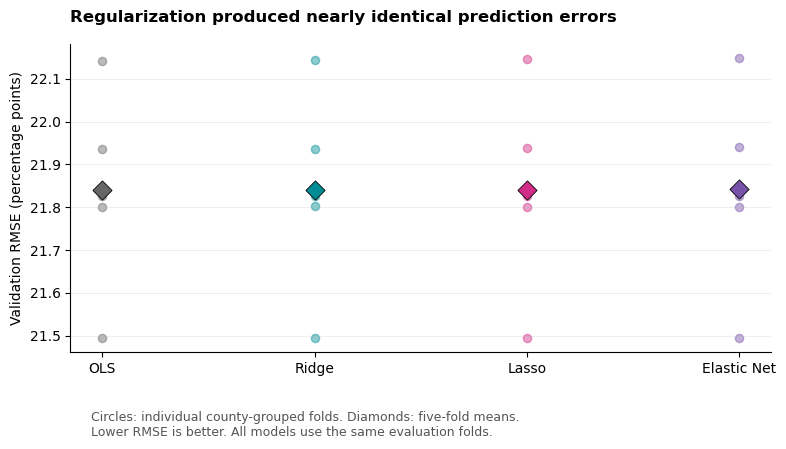

In [7]:
model_order = ["OLS", "Ridge", "Lasso", "Elastic Net"]
colors = ["#666666", "#008C95", "#D12C87", "#7953A9"]

fig, ax = plt.subplots(figsize=(8, 4.5))

for position, (name, color) in enumerate(zip(model_order, colors)):
    values = cv_results.loc[
        cv_results["Model"] == name, "RMSE (pp)"
    ]

    ax.scatter(
        np.repeat(position, len(values)),
        values,
        color=color,
        alpha=0.45,
        s=35
    )

    ax.scatter(
        position,
        values.mean(),
        color=color,
        marker="D",
        s=95,
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

ax.set_xticks(range(4))
ax.set_xticklabels(model_order)
ax.set_ylabel("Validation RMSE (percentage points)")
ax.set_title(
    "Regularization produced nearly identical prediction errors",
    loc="left",
    fontweight="bold",
    pad=16
)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

fig.text(
    0.12, 0.02,
    "Circles: individual county-grouped folds. Diamonds: five-fold means.\n"
    "Lower RMSE is better. All models use the same evaluation folds.",
    fontsize=9,
    color="#555555"
)

fig.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

### Education Coefficients
This chart shows only education terms; the fitted models still include all adjustment variables. Points are mean standardized coefficients across training folds. Quadratic and interaction terms must be interpreted together. Interaction coefficients are not total year-specific education slopes.

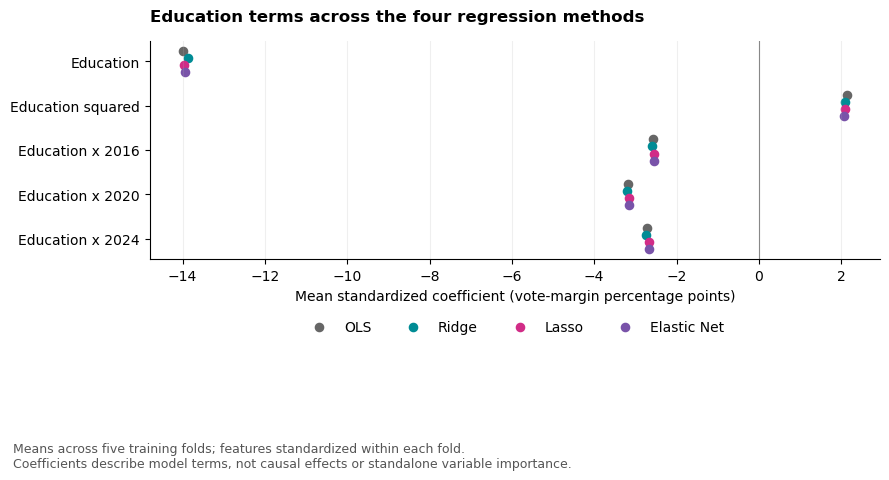

Terms set to approximately zero (absolute coefficient ≤ 1e-8):


,Model,Fold,Removed term
0,Elastic Net,3,RUCC 4


In [8]:
# Compare coefficients across the five fitted training folds.
from sklearn.base import clone

model_order = ["OLS", "Ridge", "Lasso", "Elastic Net"]
colors = ["#666666", "#008C95", "#D12C87", "#7953A9"]
coefficient_records = []
removed_records = []

splits = list(GroupKFold(n_splits=5).split(X, y, groups))

for fold, (train_idx, _) in enumerate(splits, start=1):
    # Refit OLS independently so each stored fit belongs to its own fold.
    ols_fit = make_pipeline(LinearRegression())
    ols_fit.fit(X.iloc[train_idx], y.iloc[train_idx])

    for name in model_order:
        fitted = (
            ols_fit if name == "OLS"
            else fold_models[(fold, name)]
        )
        names = fitted.named_steps["features"].transform(
            X.iloc[:1]
        ).columns
        coefficients = fitted.named_steps["model"].coef_

        for feature, coefficient in zip(names, coefficients):
            coefficient_records.append({
                "Model": name,
                "Fold": fold,
                "Feature": feature,
                "Coefficient_pp": 100 * coefficient
            })
            if abs(coefficient) <= 1e-8:
                removed_records.append({
                    "Model": name,
                    "Fold": fold,
                    "Removed term": feature
                })

coefficient_df = pd.DataFrame(coefficient_records)
coefficient_means = coefficient_df.pivot_table(
    index="Feature",
    columns="Model",
    values="Coefficient_pp",
    aggfunc="mean"
)
feature_order = ["Education", "Education squared", "Education x 2016", "Education x 2020", "Education x 2024"]
coefficient_means = coefficient_means.loc[feature_order, model_order]

fig, ax = plt.subplots(figsize=(9, 4.8))
positions = np.arange(len(feature_order))
offsets = [-0.24, -0.08, 0.08, 0.24]

for name, color, offset in zip(model_order, colors, offsets):
    ax.scatter(
        coefficient_means[name],
        positions + offset,
        label=name,
        color=color,
        s=35
    )

ax.set_yticks(positions)
ax.set_yticklabels(feature_order)
ax.invert_yaxis()
ax.axvline(0, color="#888888", linewidth=0.8)
ax.set_xlabel("Mean standardized coefficient (vote-margin percentage points)")
ax.set_title(
    "Education terms across the four regression methods",
    loc="left",
    fontweight="bold",
    pad=14
)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.22))
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
fig.text(
    0.02, 0.015,
    "Means across five training folds; features standardized within each fold.\n"
    "Coefficients describe model terms, not causal effects or standalone variable importance.",
    fontsize=9,
    color="#555555"
)
fig.tight_layout(rect=[0, 0.18, 1, 1])
plt.show()

if removed_records:
    print("Terms set to approximately zero (absolute coefficient ≤ 1e-8):")
    display(pd.DataFrame(removed_records))
else:
    print("All fitted models retained all candidate terms.")

## 4. Conclusion and Limitations

### Findings and Expectations

Regularization did not materially improve prediction for this county-year panel and candidate feature set. OLS achieved a mean validation RMSE of **21.8393 percentage points** and **R² of 0.5390**. Ridge, lasso, and elastic net produced nearly identical performance.

I expected regularization might help because education, squared education, and education-by-year interaction terms contain overlapping information. Instead, the selected penalties changed the education coefficients only slightly and provided little model simplification. Lasso retained all 18 candidate terms in every fold. Elastic net removed only the RUCC category 4 indicator in one fold; no education term was removed.

OLS therefore remains a reasonable reference model for this specification. These results do not show that regularization is generally ineffective; they show that it offered little additional predictive value here.

### Connection to the Capstone

Week 1 examined curvature and election-year differences in the education–vote-margin relationship. Week 2 retained those terms and tested whether regularization improved prediction or simplified the model while accounting for income, racial composition, geography, and election year.

### Limitations

- Validation assesses held-out counties in the observed election years, not prediction of a future election.
- The candidate features came from Week 1 exploration of this panel, so this is an exploratory comparison rather than an entirely independent final assessment.
- Some selected penalties reached the lower search boundary, leaving the precise optimal penalty near zero unresolved.
- These are county-level associations, not causal effects or conclusions about individual voters.
- Linear models do not enforce the outcome’s −1 to 1 bounds.

## 5. Sources and AI Assistance

### Sources

- DX799 Week 2 course lessons: Linear Regression Part 2.
- Corrected Week 1 RUCC notebook and the Module B Milestone 4 proposal: project context, dataset provenance, and candidate predictors.
- [Lasso vs Ridge vs Elastic Net - ML, GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/lasso-vs-ridge-vs-elastic-net-ml/)

### AI Assistance

ChatGPT assisted with adapting the Week 1 workflow for regularized regression, developing code, troubleshooting errors, and drafting interpretations of the displayed results.